# DSC 550 Term Project

## Milestone 1: Data Selection and EDA

##  Identify the problem

## Non-Voters in the US
My analysis will be to predict whether someone will vote or not based on certain demographic characteristics, and other various questions regarding people’s feelings towards candidates and the complexity of the American voting process. The dataset I chose is data from a poll that was conducted by FiveThirtyEight (https://projects.fivethirtyeight.com/non-voters-poll-2020-election/). The poll asked thirty-three questions and also included five demographic questions which are age, gender, education, race, and income category. I have included the link to the pdf of questions that FiveThirtyEight used in their poll which is named the “nonvoters_cookbook” (https://query.data.world/s/5lsj3u5now7376l6umsy4rhhrk6ehx?dws=00000). The dataset contains the responses from 5,836 surveyed people. They defined people who “always” vote as voting in all but one national election that they were eligible to vote in. They defined people who “sporadic” vote as those who voted in at least two elections but less than all the elections that they were eligible to vote in. They defined people to “rarely/never” vote as those who voted in one or less elections that they were eligible to vote in. 

Besides the demographic’s questions, there were other questions that I feel may have influence as to whether people vote. One is do people feel like elections really matter, or do they feel that nothing ever changes anyway. Another question that was asked is whether people think that those in elected offices are like themselves. They were asked whether people feel that changes are needed in the country or whether changes are not needed. They were also asked whether people find the voting process easy or hard. Finally, I will look at party affiliation and how the breakdown of what party people identify with affects their decision to vote. If we can understand better what some of the challenges with why Americans choose not to vote are, then we can look at ways to improve voter turnout which will then impact the laws and policies in this country. Everyone's voice is important!

The target variable for the model will be to predict a voter category based on the features asked in the poll and determine what feature has the greatest impact of the decision to vote always, sporadically, or rarely/never.


## Graphical Analysis

In [136]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [137]:
# open the file

nonvoters_df = pd.read_csv("C:/Users/rmtol/OneDrive/Desktop/Bellevue/DSC 550/nonvoters_data2.csv")

In [138]:
# display column names for easy reference

print(nonvoters_df.columns)

Index(['RespId', 'weight', 'Q1', 'matters_or_not', 'like_me', 'changes_needed',
       'disbility', 'chronic_illness', 'unemployed', 'evicted', 'easy_tovote',
       'registered', 'how_vote', 'vote', 'party', 'ppage', 'educ', 'race',
       'gender', 'income_cat', 'voter_category'],
      dtype='object')


In [139]:
# Some field have -1 in the response even though this was not a choice on the survey

# Will replace -1 with NaN to avoid misrepresenting the value

nonvoters_df.replace(-1, np.nan, inplace=True)

In [140]:
# using head function to display first 10 rows of data

print(nonvoters_df.head(10))

   RespId  weight  Q1  matters_or_not  like_me  changes_needed  disbility  \
0  470001  0.7516   1             1.0      2.0             1.0        2.0   
1  470002  1.0267   1             1.0      2.0             2.0        2.0   
2  470003  1.0844   1             1.0      1.0             1.0        2.0   
3  470007  0.6817   1             1.0      3.0             1.0        2.0   
4  480008  0.9910   1             1.0      2.0             2.0        2.0   
5  480009  1.0591   1             2.0      4.0             1.0        2.0   
6  480010  1.1512   1             1.0      1.0             1.0        2.0   
7  470008  1.0174   1             1.0      1.0             1.0        2.0   
8  470010  0.8184   1             1.0      3.0             1.0        2.0   
9  470011  1.1653   1             1.0      3.0             1.0        2.0   

   chronic_illness  unemployed  evicted  ...  registered  how_vote  vote  \
0              2.0         2.0      2.0  ...         1.0       1.0   1.0   


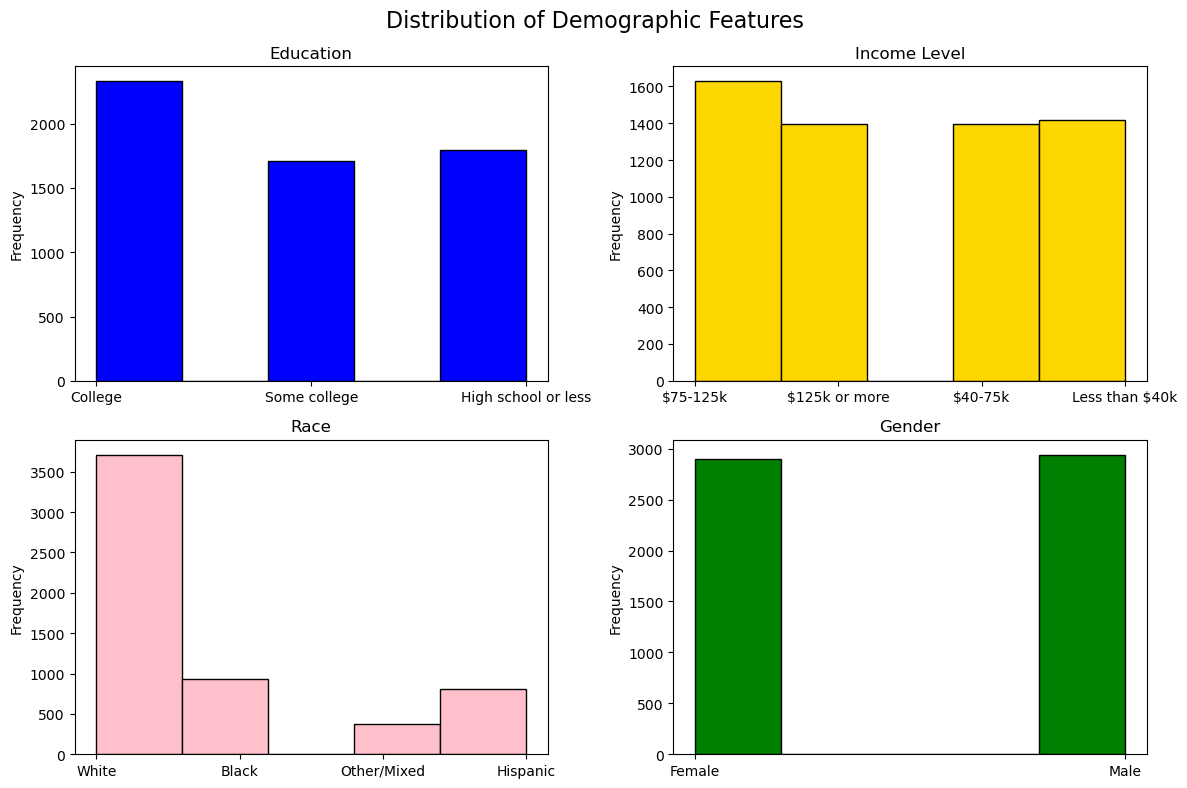

In [141]:
# Create histograms to see the distribution of the demographic features

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle("Distribution of Demographic Features", fontsize=16)

# Education
axes[0, 0].hist(nonvoters_df['educ'], bins=5, color='blue', edgecolor='black')
axes[0, 0].set_title("Education")
axes[0, 0].set_ylabel("Frequency")


# Income Level
axes[0, 1].hist(nonvoters_df['income_cat'], bins=5, color='gold', edgecolor='black')
axes[0, 1].set_title("Income Level")
axes[0, 1].set_ylabel("Frequency")


# Race
axes[1, 0].hist(nonvoters_df['race'], bins=5, color='pink', edgecolor='black')
axes[1, 0].set_title("Race")
axes[1, 0].set_ylabel("Frequency")


# Gender
axes[1, 1].hist(nonvoters_df['gender'], bins=5, color='green', edgecolor='black')
axes[1, 1].set_title("Gender")
axes[1, 1].set_ylabel("Frequency")



plt.tight_layout()
plt.show()

### The dataset has a good mixture of demographics for Education, Gender, and Income Level, however Race is not well distributed where White is more represented in the poll than other races. 

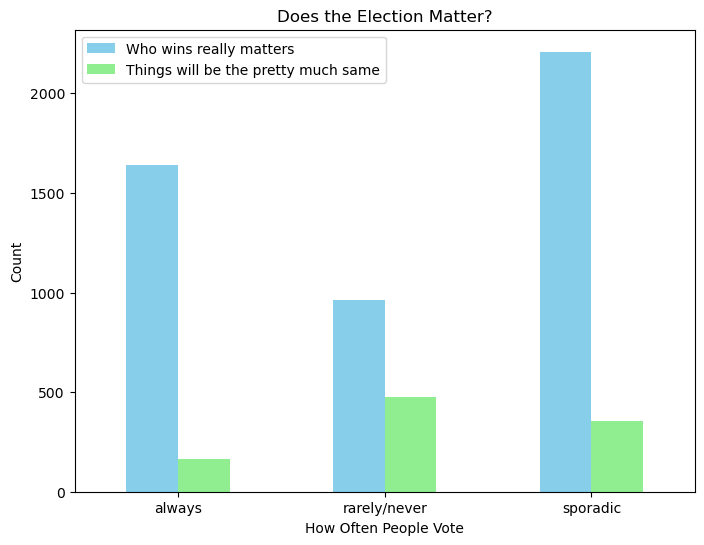

In [142]:
# Create a cross tab between voter category and whether the election matters question

crosstab_df = pd.crosstab(nonvoters_df['voter_category'], nonvoters_df['matters_or_not'])

# create a bar chart

crosstab_df.plot(kind='bar', figsize=(8, 6), color=['skyblue', 'lightgreen'])
plt.title("Does the Election Matter?")
plt.xlabel("How Often People Vote")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(labels=["Who wins really matters", "Things will be the pretty much same"])
plt.show()

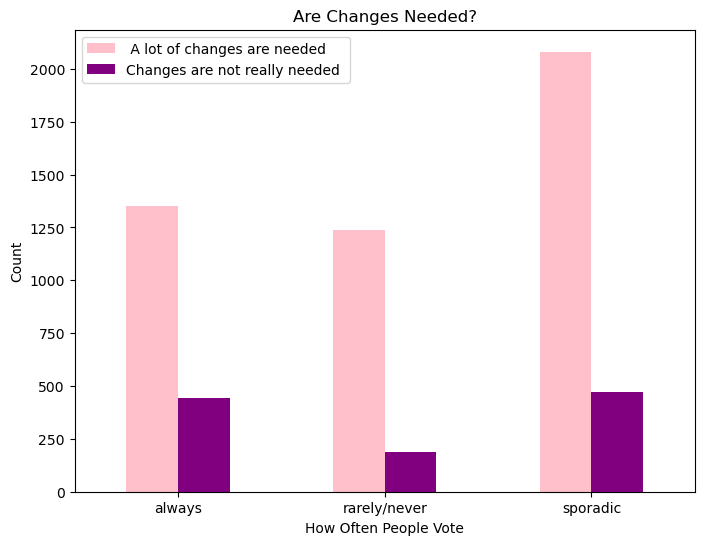

In [143]:
# Create a cross tab between voter category and whether people think changes are needed

crosstab_df = pd.crosstab(nonvoters_df['voter_category'], nonvoters_df['changes_needed'])

# create a bar chart

crosstab_df.plot(kind='bar', figsize=(8, 6), color=['pink', 'purple'])
plt.title("Are Changes Needed?")
plt.xlabel("How Often People Vote")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(labels=[" A lot of changes are needed", "Changes are not really needed "])
plt.show()

### Whether people vote always, sporadic, or rarely, most think that who wins matters, and most think that a lot of changes are needed. 

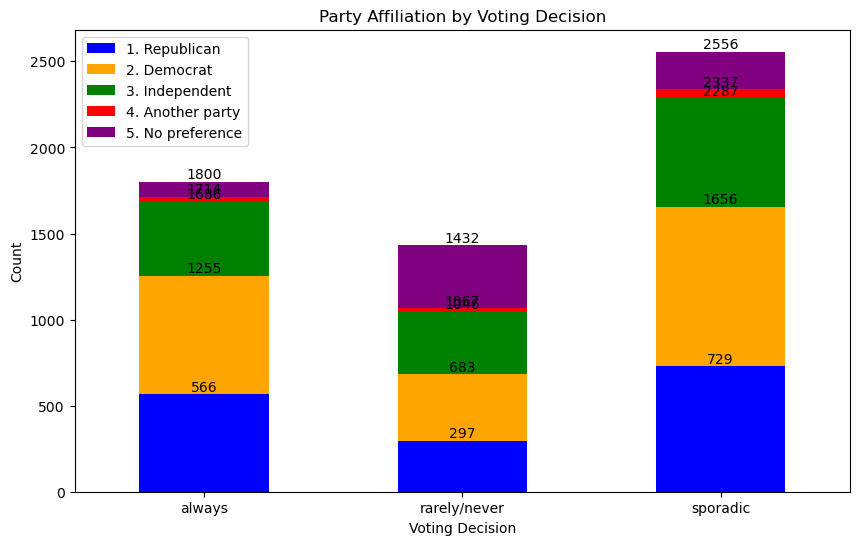

In [144]:
# Create a cross tav between voter category and party affiliation
crosstab_df = pd.crosstab(nonvoters_df['voter_category'], nonvoters_df['party'])

colors = ["blue", "orange", "green", "red", "purple"]

# create a stacked bar chart
ax = crosstab_df.plot(kind='bar', stacked=True, figsize=(10, 6), color = colors)
plt.title("Party Affiliation by Voting Decision")
plt.xlabel("Voting Decision")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(labels=["1. Republican", "2. Democrat", "3. Independent", "4. Another party", "5. No preference"])

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=10, color='black')


plt.show()

### There is pretty even breakdown for the parties Republican, Democrat, Independent, and Another regardless of voting decision. No preference is the only one that has significant changes.  No preference is also the highest for never voting. 

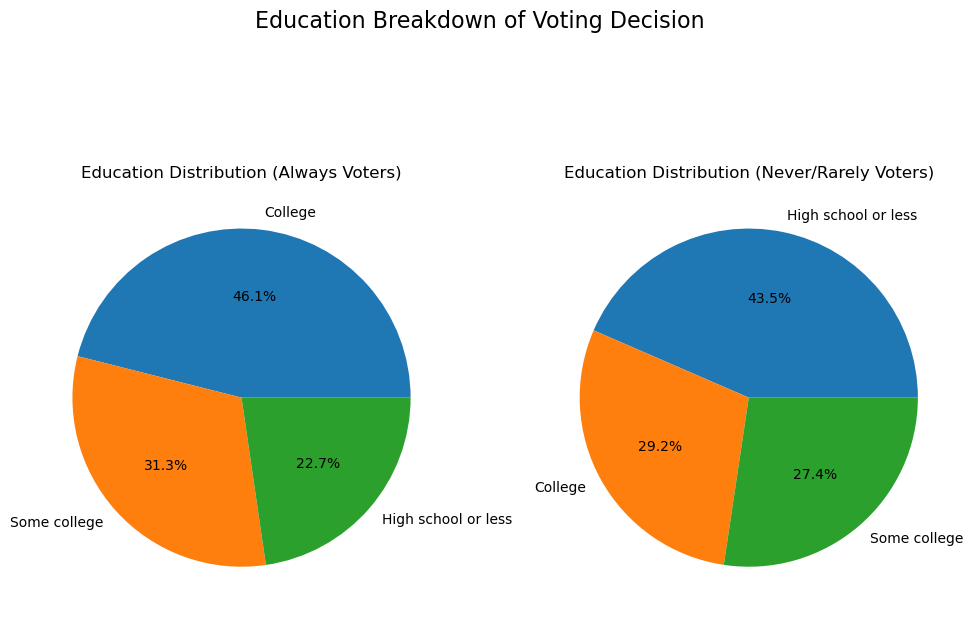

<Figure size 600x600 with 0 Axes>

In [145]:
# create pie charts for Education level on voting category

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
fig.suptitle("Education Breakdown of Voting Decision", fontsize=16)

# filter rows where voter_category is "always"

alwaysvote_df = nonvoters_df[nonvoters_df['voter_category'] == 'always']

# filter rows where voter_category is "rarely/never"

nevervote_df = nonvoters_df[nonvoters_df['voter_category'] == 'rarely/never']


# Create pie charts

plt.figure(figsize=(6,6))
alwaysvote_df['educ'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax = axes[0])
axes[0].set_title("Education Distribution (Always Voters)")
axes[0].set_ylabel("")

nevervote_df['educ'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title("Education Distribution (Never/Rarely Voters)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### College level has the highest in always voting while highschool or less has the largest in not voting. 

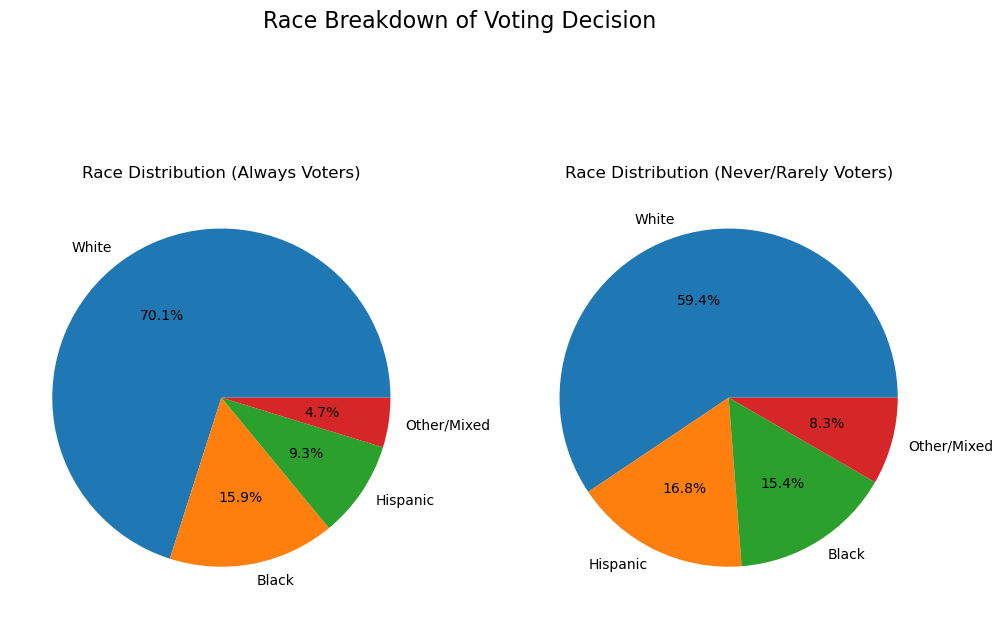

<Figure size 600x600 with 0 Axes>

In [146]:
# create pie charts for Race on voting category

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
fig.suptitle("Race Breakdown of Voting Decision", fontsize=16)

# filter rows where voter_category is "always"

racealwaysvote_df = nonvoters_df[nonvoters_df['voter_category'] == 'always']

# filter rows where voter_category is "rarely/never"

racenevervote_df = nonvoters_df[nonvoters_df['voter_category'] == 'rarely/never']


# Create pie charts

plt.figure(figsize=(6,6))
racealwaysvote_df['race'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax = axes[0])
axes[0].set_title("Race Distribution (Always Voters)")
axes[0].set_ylabel("")

racenevervote_df['race'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title("Race Distribution (Never/Rarely Voters)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### White race has the highest in both always vote and never vote, but we saw in the distribution graphs that the other races were under represented in the data so this makes sense.  

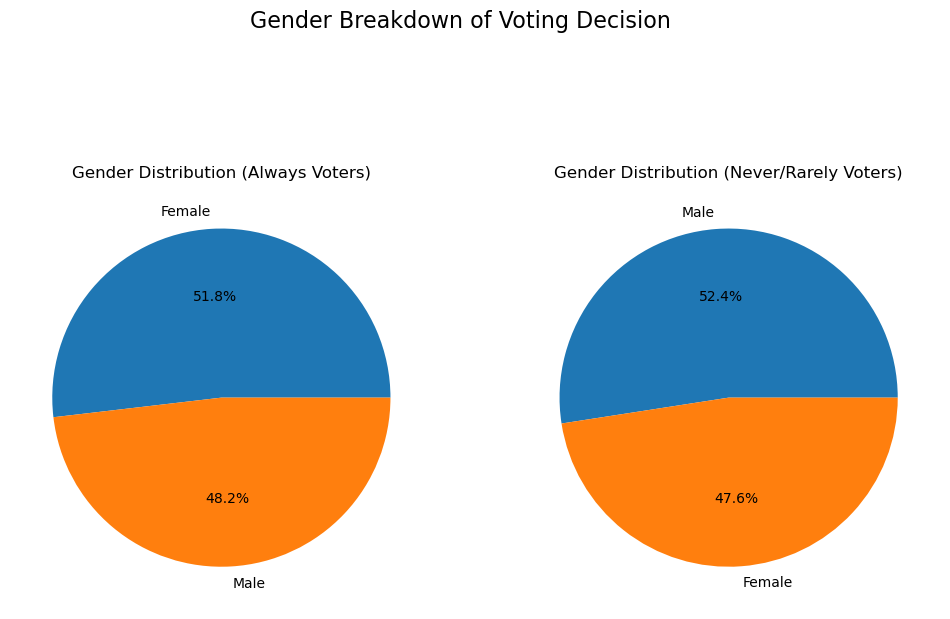

<Figure size 600x600 with 0 Axes>

In [147]:
# create pie charts for Gender on voting category

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
fig.suptitle("Gender Breakdown of Voting Decision", fontsize=16)

# filter rows where voter_category is "always"

genderalwaysvote_df = nonvoters_df[nonvoters_df['voter_category'] == 'always']

# filter rows where voter_category is "rarely/never"

gendernevervote_df = nonvoters_df[nonvoters_df['voter_category'] == 'rarely/never']


# Create pie charts

plt.figure(figsize=(6,6))
genderalwaysvote_df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax = axes[0])
axes[0].set_title("Gender Distribution (Always Voters)")
axes[0].set_ylabel("")

gendernevervote_df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title("Gender Distribution (Never/Rarely Voters)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Very close numbers for gender however women have slightly higher numbers in the always vote and men have slightly higher in the never vote.

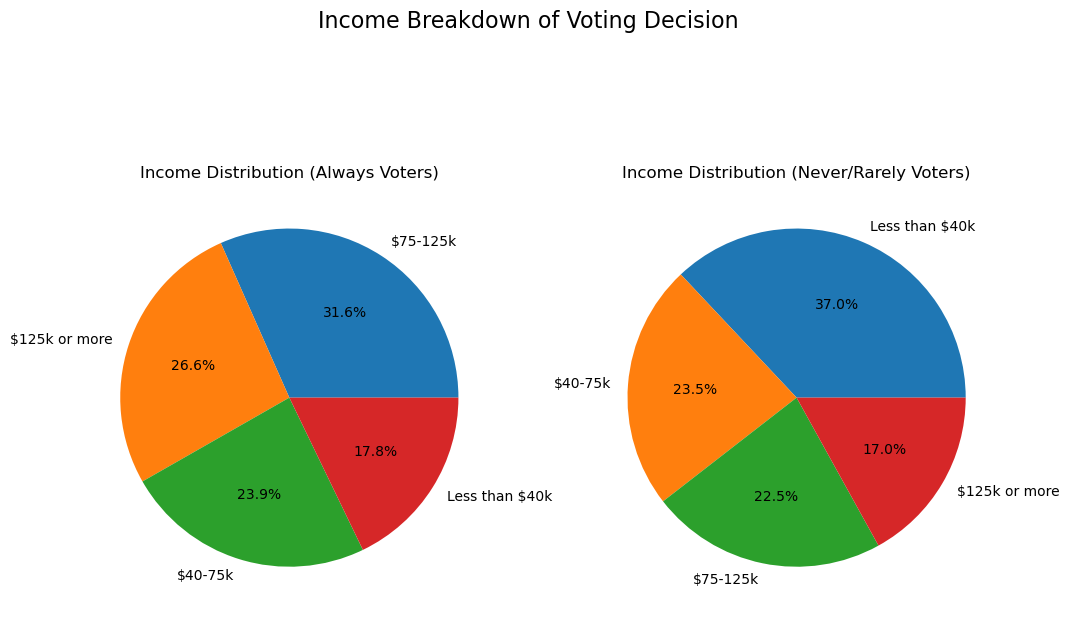

<Figure size 600x600 with 0 Axes>

In [148]:
# create pie charts for Income on voting category

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
fig.suptitle("Income Breakdown of Voting Decision", fontsize=16)

# filter rows where voter_category is "always"

inalwaysvote_df = nonvoters_df[nonvoters_df['voter_category'] == 'always']

# filter rows where voter_category is "rarely/never"

innevervote_df = nonvoters_df[nonvoters_df['voter_category'] == 'rarely/never']


# Create pie charts

plt.figure(figsize=(6,6))
inalwaysvote_df['income_cat'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax = axes[0])
axes[0].set_title("Income Distribution (Always Voters)")
axes[0].set_ylabel("")

innevervote_df['income_cat'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title("Income Distribution (Never/Rarely Voters)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### For income level, those in the higher two income brackets tend to vote always while those in the lower two income brackets vote never. 

In [149]:
# create age bins and labels for a new column

age_bins = [22, 30, 49, 67, float('inf')]
age_labels = ['Young adults', 'Middle Age adults', 'Older adults', 'Senior citizens']

# create a new column for age category

nonvoters_df['age_category'] = pd.cut(nonvoters_df['ppage'], bins=age_bins, labels=age_labels, right=False)

In [150]:
print(nonvoters_df.head())

   RespId  weight  Q1  matters_or_not  like_me  changes_needed  disbility  \
0  470001  0.7516   1             1.0      2.0             1.0        2.0   
1  470002  1.0267   1             1.0      2.0             2.0        2.0   
2  470003  1.0844   1             1.0      1.0             1.0        2.0   
3  470007  0.6817   1             1.0      3.0             1.0        2.0   
4  480008  0.9910   1             1.0      2.0             2.0        2.0   

   chronic_illness  unemployed  evicted  ...  how_vote  vote  party  ppage  \
0              2.0         2.0      2.0  ...       1.0   1.0    2.0     73   
1              2.0         2.0      2.0  ...       3.0   1.0    3.0     90   
2              2.0         1.0      2.0  ...       1.0   1.0    2.0     53   
3              2.0         2.0      2.0  ...       1.0   1.0    2.0     58   
4              2.0         2.0      2.0  ...       3.0   1.0    1.0     81   

                  educ   race  gender     income_cat voter_category 

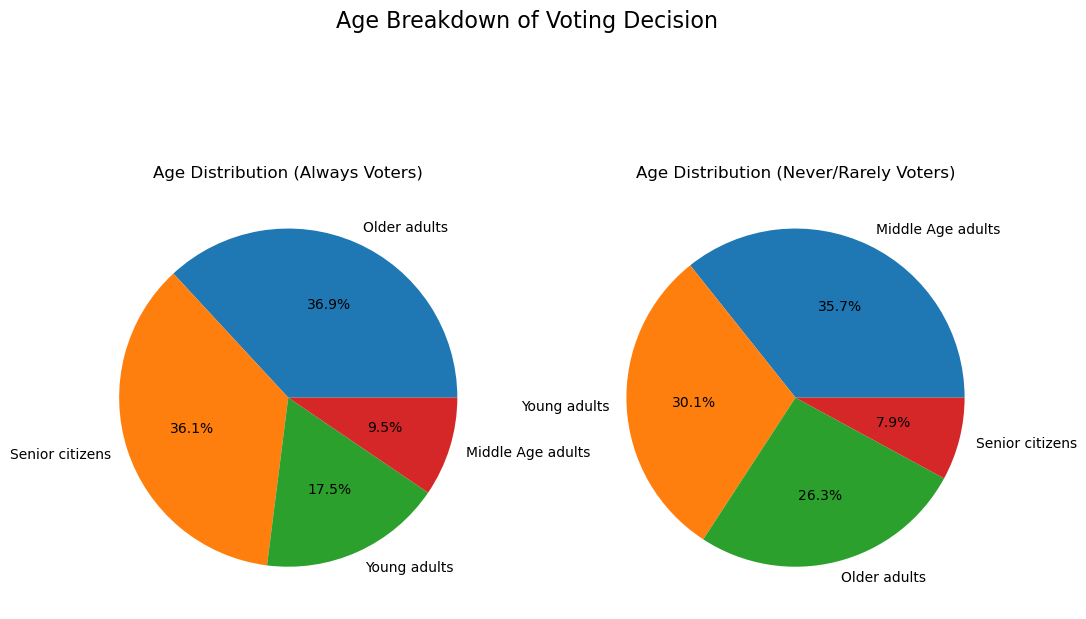

<Figure size 600x600 with 0 Axes>

In [151]:
# create pie charts for Age category on voting category

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
fig.suptitle("Age Breakdown of Voting Decision", fontsize=16)

# filter rows where voter_category is "always"

agealwaysvote_df = nonvoters_df[nonvoters_df['voter_category'] == 'always']

# filter rows where voter_category is "rarely/never"

agenevervote_df = nonvoters_df[nonvoters_df['voter_category'] == 'rarely/never']


# Create pie charts

plt.figure(figsize=(6,6))
agealwaysvote_df['age_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax = axes[0])
axes[0].set_title("Age Distribution (Always Voters)")
axes[0].set_ylabel("")

agenevervote_df['age_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
axes[1].set_title("Age Distribution (Never/Rarely Voters)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### The age pie charts shows that more older adults and seniors always vote and more middle aged adults and young adults never vote. 

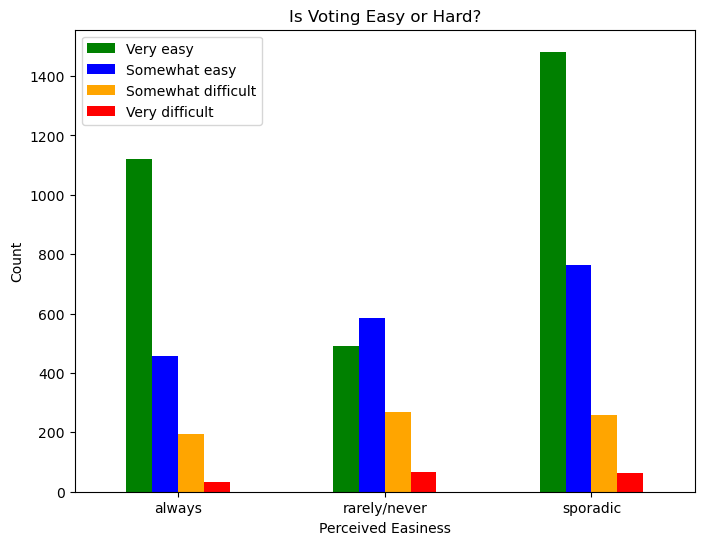

In [152]:
# Create a cross tab between voter category and whether people think voting is easy

crosstab_df = pd.crosstab(nonvoters_df['voter_category'], nonvoters_df['easy_tovote'])

# create a bar chart

crosstab_df.plot(kind='bar', figsize=(8, 6), color=['green', 'blue', 'orange', 'red'])
plt.title("Is Voting Easy or Hard?")
plt.xlabel("Perceived Easiness")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(labels= ["Very easy", "Somewhat easy", "Somewhat difficult", "Very difficult"])
plt.show()

### Those who never vote do not think voting is easy. They find it somewhat easy and somewhat difficult. No group really finds voting difficult. 

### In conclusion the graphs tell us that the three main factors which affect how often people vote are education level, income level, and age. Those with college level education, higher income level, and old age tend to vote always while those with no college, lower income level, and younger age tend to vote less. Race may be a valid factor, but due to the uneven distribution of race for the people participating in the poll, I could not make any conclusions about race. 

## Milestone 2: Data Preparation

### Rename a column

In [153]:
# check the shape

nonvoters_df.shape

(5836, 22)

In [154]:
# rename Q1 to Citizen to better understand the value of the question

nonvoters_df.rename(columns = {'Q1' : 'citizen'},  inplace = True)

In [155]:
print(nonvoters_df.columns)

Index(['RespId', 'weight', 'citizen', 'matters_or_not', 'like_me',
       'changes_needed', 'disbility', 'chronic_illness', 'unemployed',
       'evicted', 'easy_tovote', 'registered', 'how_vote', 'vote', 'party',
       'ppage', 'educ', 'race', 'gender', 'income_cat', 'voter_category',
       'age_category'],
      dtype='object')


### Add a column for how difficult people think voting is

In [156]:
# create easy_tovote bins and labels for a new column

easy_values = [1, 2, 3, 4, float('inf')]
easy_labels = ['Very easy', 'Somewhat easy', 'Somewhat difficult', 'Very difficult']

In [157]:
# create a new column for easy to vote

nonvoters_df['voting_accessibility'] = pd.cut(nonvoters_df['easy_tovote'], bins=easy_values, labels=easy_labels, right=False)

In [158]:
print(nonvoters_df.columns)

Index(['RespId', 'weight', 'citizen', 'matters_or_not', 'like_me',
       'changes_needed', 'disbility', 'chronic_illness', 'unemployed',
       'evicted', 'easy_tovote', 'registered', 'how_vote', 'vote', 'party',
       'ppage', 'educ', 'race', 'gender', 'income_cat', 'voter_category',
       'age_category', 'voting_accessibility'],
      dtype='object')


In [159]:
nonvoters_df.head()

,RespId,weight,citizen,matters_or_not,like_me,changes_needed,disbility,chronic_illness,unemployed,evicted,...,vote,party,ppage,educ,race,gender,income_cat,voter_category,age_category,voting_accessibility
0,470001,0.7516,1,1.0,2.0,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,73,College,White,Female,$75-125k,always,Senior citizens,Very easy
1,470002,1.0267,1,1.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1.0,3.0,90,College,White,Female,$125k or more,always,Senior citizens,Somewhat easy
2,470003,1.0844,1,1.0,1.0,1.0,2.0,2.0,1.0,2.0,...,1.0,2.0,53,College,White,Male,$125k or more,sporadic,Older adults,Very easy
3,470007,0.6817,1,1.0,3.0,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,58,Some college,Black,Female,$40-75k,sporadic,Older adults,Very difficult
4,480008,0.9910,1,1.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,81,High school or less,White,Male,$40-75k,always,Senior citizens,Very easy


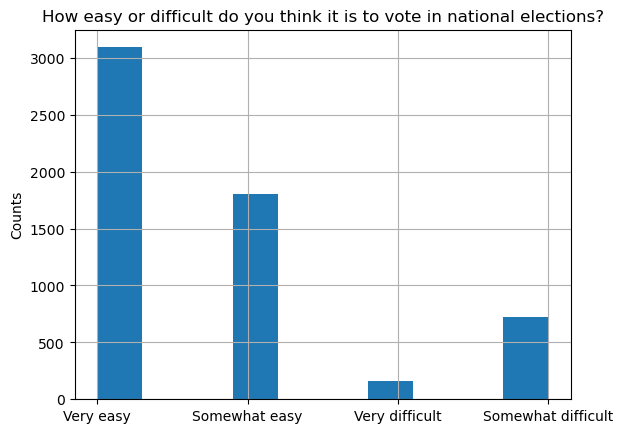

In [160]:
# create a histogram for the new column's distribution

nonvoters_df['voting_accessibility'].hist()
plt.ylabel('Counts')
plt.title('How easy or difficult do you think it is to vote in national elections?')
plt.show()

### Drop Columns

In [161]:
# drop columns
# gender and party because we found in the graphical anaysis that these columns did not effect whether a person votes 
# race because the distribution of race among the participants is very uneven, with White far exceeding others
# RespId is a unique respondent ID 
# vote because it is the same information as the target variable
# weight

nonvoters_df.drop(columns=['RespId', 'weight', 'party', 'race', 'gender', 'vote'], inplace=True)

In [162]:
# display column names to check

print(nonvoters_df.columns)

Index(['citizen', 'matters_or_not', 'like_me', 'changes_needed', 'disbility',
       'chronic_illness', 'unemployed', 'evicted', 'easy_tovote', 'registered',
       'how_vote', 'ppage', 'educ', 'income_cat', 'voter_category',
       'age_category', 'voting_accessibility'],
      dtype='object')


### Create Dummy variables

In [163]:
# check the feature types

nonvoters_df.dtypes

citizen                    int64
matters_or_not           float64
like_me                  float64
changes_needed           float64
disbility                float64
chronic_illness          float64
unemployed               float64
evicted                  float64
easy_tovote              float64
registered               float64
how_vote                 float64
ppage                      int64
educ                      object
income_cat                object
voter_category            object
age_category            category
voting_accessibility    category
dtype: object

In [164]:
# convert the categorical features into dummy variables.
# drop_first=True to avoid multicollinearity amongst the dummy variables

# age category, education, income category, voter category, voting accessibility


nonvoters_df_dummies = pd.get_dummies(nonvoters_df,columns=
                                ['educ','income_cat','voter_category','age_category','voting_accessibility'],
                               drop_first=True) 

In [165]:
# display column names to check

print(nonvoters_df_dummies.columns)

Index(['citizen', 'matters_or_not', 'like_me', 'changes_needed', 'disbility',
       'chronic_illness', 'unemployed', 'evicted', 'easy_tovote', 'registered',
       'how_vote', 'ppage', 'educ_High school or less', 'educ_Some college',
       'income_cat_$40-75k', 'income_cat_$75-125k',
       'income_cat_Less than $40k', 'voter_category_rarely/never',
       'voter_category_sporadic', 'age_category_Middle Age adults',
       'age_category_Older adults', 'age_category_Senior citizens',
       'voting_accessibility_Somewhat easy',
       'voting_accessibility_Somewhat difficult',
       'voting_accessibility_Very difficult'],
      dtype='object')


In [166]:
# check the feature types to check

nonvoters_df_dummies.dtypes

citizen                                      int64
matters_or_not                             float64
like_me                                    float64
changes_needed                             float64
disbility                                  float64
chronic_illness                            float64
unemployed                                 float64
evicted                                    float64
easy_tovote                                float64
registered                                 float64
how_vote                                   float64
ppage                                        int64
educ_High school or less                     uint8
educ_Some college                            uint8
income_cat_$40-75k                           uint8
income_cat_$75-125k                          uint8
income_cat_Less than $40k                    uint8
voter_category_rarely/never                  uint8
voter_category_sporadic                      uint8
age_category_Middle Age adults 

### Drop rows with missing data

In [167]:
# drop any rows wth missing data

nonvoters_df_dummies.dropna(inplace=True)

In [168]:
# check dimensions to check
# prior dimensions were (5836, 22)

dimensions = nonvoters_df_dummies.shape
print(dimensions)

(5633, 25)


#### rows deleted are 203

### 3. Split the data into a training and test set, where the “voter_category” column is the target.

In [169]:
# Split the data into a training and test set with 80/20 break
# voter_category_rarely/never is the target
# remove the other voter category (voter_category_sporadic)

# X features and y target variable


X = nonvoters_df_dummies.drop(columns=['voter_category_rarely/never', 'voter_category_sporadic'])  

# y target voter_category

y = nonvoters_df_dummies['voter_category_rarely/never']


In [170]:
# split the data with test size is 20% 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=100)

In [171]:
print(f"The Training data size is: {len(X_train)}")
print(f"The Test data size is: {len(X_test)}")

The Training data size is: 4506
The Test data size is: 1127


In [172]:
# re-check the shape

X_train.shape
X_test.shape

(1127, 23)

### Check missing values

In [173]:
# check for missing values in the Train and Test sets

missing_valuestrain = X_train.isnull().sum()
missing_valuestest = X_test.isnull().sum()

In [174]:
print("The missing values in each feature are:")
print(missing_valuestrain)
print(missing_valuestest)

The missing values in each feature are:
citizen                                    0
matters_or_not                             0
like_me                                    0
changes_needed                             0
disbility                                  0
chronic_illness                            0
unemployed                                 0
evicted                                    0
easy_tovote                                0
registered                                 0
how_vote                                   0
ppage                                      0
educ_High school or less                   0
educ_Some college                          0
income_cat_$40-75k                         0
income_cat_$75-125k                        0
income_cat_Less than $40k                  0
age_category_Middle Age adults             0
age_category_Older adults                  0
age_category_Senior citizens               0
voting_accessibility_Somewhat easy         0
voting_accessib

In [175]:
X_train.head()

,citizen,matters_or_not,like_me,changes_needed,disbility,chronic_illness,unemployed,evicted,easy_tovote,registered,...,educ_Some college,income_cat_$40-75k,income_cat_$75-125k,income_cat_Less than $40k,age_category_Middle Age adults,age_category_Older adults,age_category_Senior citizens,voting_accessibility_Somewhat easy,voting_accessibility_Somewhat difficult,voting_accessibility_Very difficult
55,1,1.0,3.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,...,0,1,0,0,1,0,0,1,0,0
3943,1,2.0,4.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,...,0,1,0,0,0,1,0,1,0,0
2738,1,1.0,2.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,...,0,0,1,0,1,0,0,0,0,0
4585,1,1.0,2.0,1.0,2.0,2.0,2.0,2.0,3.0,1.0,...,0,0,1,0,0,0,0,0,1,0
2561,1,1.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,...,0,0,1,0,0,1,0,0,0,0


### Use a χ2-statistic selector to pick the five best features for this data

In [176]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2, f_classif

In [177]:
# load data

featuresvoters = X_train
targetvoters = y_train

In [178]:
# select 5 features with highest chi-squared statistics

chi2_selector = SelectKBest(chi2, k = 5)
features_kbest = chi2_selector.fit_transform(featuresvoters, targetvoters)

In [179]:
# show results

print ("Original number of features:", featuresvoters.shape[1])
print ("Reduced number of features:", features_kbest.shape[1])

Original number of features: 23
Reduced number of features: 5


In [180]:
# get the selected features

selected_features = chi2_selector.get_support(indices=True)

In [181]:
# get the names of the selected features

selected_features_names = list(X_train.columns[selected_features])

In [182]:
print("The Five Selected Features are:")
print(selected_features_names)

The Five Selected Features are:
['easy_tovote', 'ppage', 'educ_High school or less', 'income_cat_Less than $40k', 'age_category_Senior citizens']


### The 5 features are:

1. easy_tovote
2. ppage - Age of respondent
3. educ_High school or less
4. income_cat_Less than $40k
5. age_category_Senior citizens

### Summary of Changes in Milestone 2

- Renamed one column to understand the question
- Created a new column and checked distribution with a histogram
- Dropped columns
- Created Dummy variables
- Checked for missing values and filled it in with the mode
- Split data into Training and Test
- Ran SelectKBest to find the 5 features with the most effect on the target

## Milestone 3: Model Building and Evaluation

### Run a logistic regression model and Confusion matrix

In [183]:
from sklearn.linear_model import LogisticRegression

In [184]:
# create and train a logistic regression model and fit the model to the training data

log_model = LogisticRegression(max_iter = 500, solver='liblinear')

log_model.fit(X_train, y_train)


LogisticRegression(max_iter=500, solver='liblinear')

In [185]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [186]:
y_pred = log_model.predict(X_test)

In [187]:
# set a different threshold

new_threshold = 0.2
y_pred_new = (y_pred >= new_threshold).astype(int)

In [188]:
accuracy = accuracy_score(y_test, y_pred_new)

print('Accuracy Score:', accuracy)

Accuracy Score: 0.8402839396628217


In [189]:
# create a confusion matrix

conf_matrix = confusion_matrix(y_test, y_pred_new)
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[847  21]
 [159 100]]


In [190]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

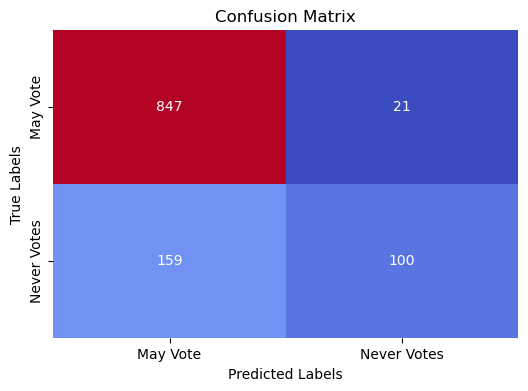

In [191]:
# in the target variable column 0 represents voter is not in the voting never category
# in the target variable column 1 represents voter is in the voting never category

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", cbar=False,
            xticklabels=["May Vote", "Never Votes"], yticklabels=["May Vote", "Never Votes"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

#### Findings:
- The top left 847 represents true positives, correctly predicted May Vote
- Top right 21 represents false negatives, predicted Never Votes, but May Vote
- Bottom left 159 represents false positives, predicted May Vote, but Never Votes
- Bottom right 100 represents true negatives, correctly predicted Never Votes

In [192]:
# get feature coefficients

coefficients = log_model.coef_[0]

In [193]:
# sort the coefficients

indices_lr = np.argsort(np.abs(coefficients))[::-1]

In [194]:
# get the feature names

feature_names_lr = X_train.columns

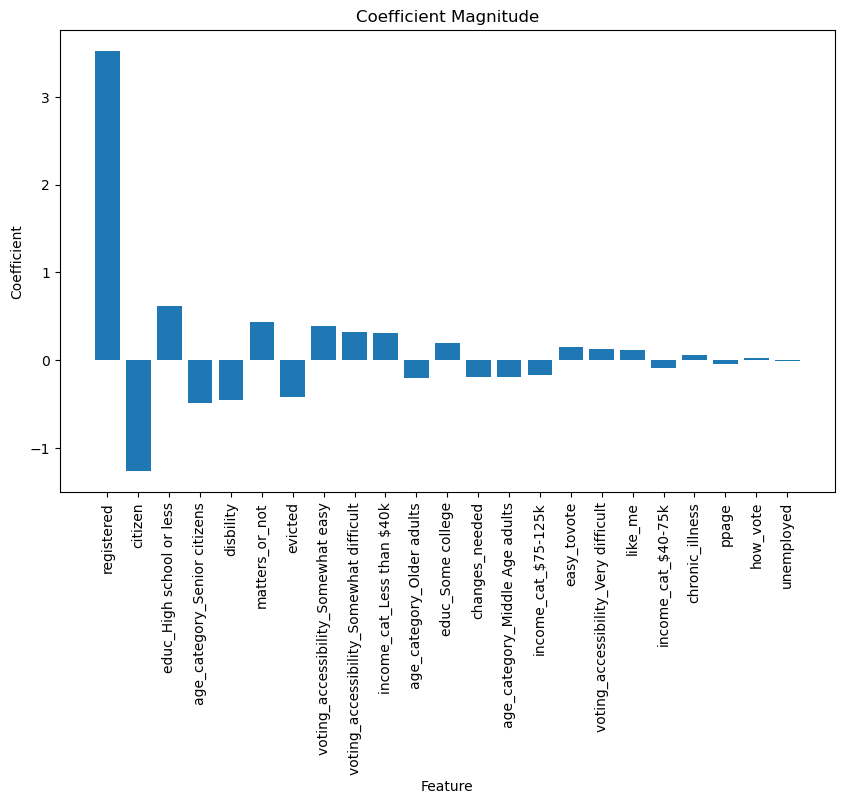

In [195]:
#  plot the features from logisitic regression

plt.figure(figsize=(10, 6))
plt.bar(range(len(coefficients)), coefficients[indices_lr], align="center")
plt.xticks(range(len(coefficients)), [feature_names_lr[i] for i in indices_lr], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.title("Coefficient Magnitude")
plt.show()

#### For Logistic Regression, whether the person is registered to vote or not has the highest impact on not voting.

### Run a decision tree classifier on the training set

In [196]:
from sklearn.tree import DecisionTreeClassifier

In [197]:
# create a classifier

classifier = DecisionTreeClassifier(random_state=42)

In [198]:
# fit the classifier

classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [199]:
# make a prediction on the test set

y_pred_dt = classifier.predict(X_test)

In [200]:
# report the accuracy

accuracy_dt = accuracy_score(y_test, y_pred_dt)

In [201]:
print(f"The decision tree accuracy on the test set: {accuracy_dt:.4f}")

The decision tree accuracy on the test set: 0.7471


In [202]:
from sklearn.tree import plot_tree

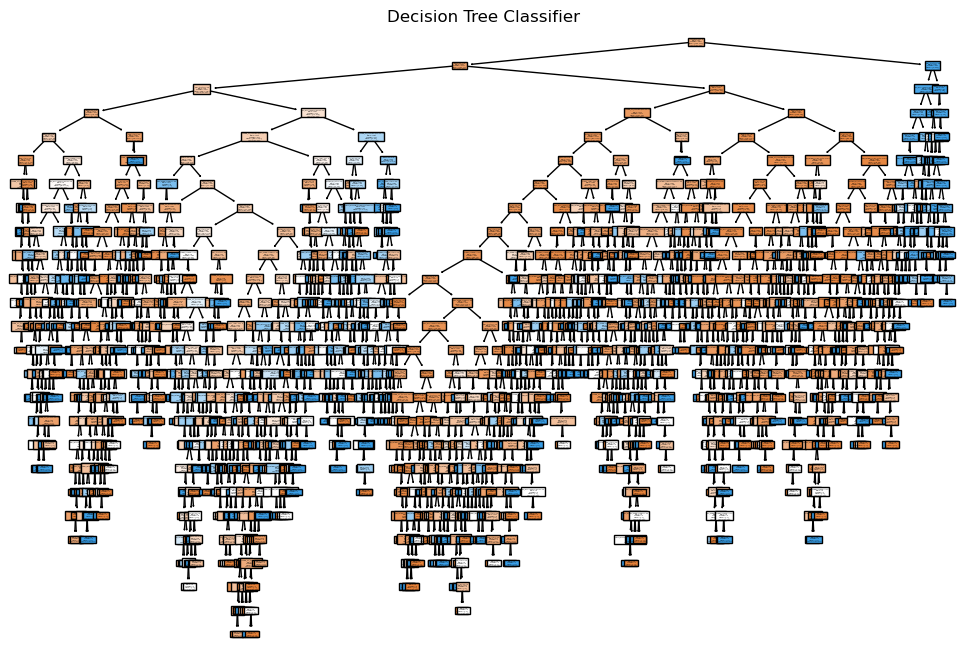

In [203]:
# decision tree plot
feature_names_list = list(nonvoters_df_dummies.columns)

plt.figure(figsize=(12, 8))
plot_tree(classifier, filled = True, feature_names=feature_names_list , class_names=["May Vote", "Never Votes"])
plt.title("Decision Tree Classifier")
plt.show()

### Run a logisitc model on the 5 best features from the χ2-statistic selector done in Milestone 2

In [204]:
# Split the data in to training and test sets

X_best = nonvoters_df_dummies[
    ['easy_tovote', 'ppage', 'educ_High school or less', 'income_cat_Less than $40k', 'age_category_Senior citizens']]

# target

y_best = nonvoters_df_dummies['voter_category_rarely/never']

In [205]:
# split the data with test size is 20% 

X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(X_best, y_best, test_size=0.2, random_state=100)

In [206]:
print(f"The Training data size is: {len(X_train_best)}")
print(f"The Test data size is: {len(X_test_best)}")

The Training data size is: 4506
The Test data size is: 1127


In [207]:
# create and train a logistic regression model and fit the model to the training data

log_model_5 = LogisticRegression(max_iter = 500, solver='liblinear')

log_model_5.fit(X_train_best, y_train_best)

LogisticRegression(max_iter=500, solver='liblinear')

In [208]:
y_pred_5 = log_model_5.predict(X_test_best)

In [209]:
accuracy_5 = accuracy_score(y_test_best, y_pred_5)

print('Accuracy Score:', accuracy_5)

Accuracy Score: 0.7834960070984915


In [210]:
# create a confusion matrix

conf_matrix_5 = confusion_matrix(y_test_best, y_pred_5)
print("Confusion Matrix 5 Best:")
print(conf_matrix_5)

Confusion Matrix 5 Best:
[[811  57]
 [187  72]]


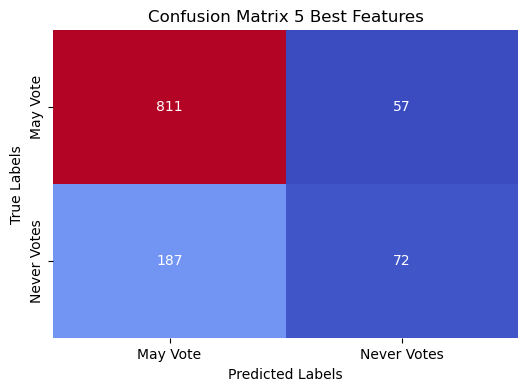

In [211]:
# in the target variable column 0 represents voter is not in the voting never category
# in the target variable column 1 represents voter is in the voting never category

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_5, annot=True, fmt="d", cmap="coolwarm", cbar=False,
            xticklabels=["May Vote", "Never Votes"], yticklabels=["May Vote", "Never Votes"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix 5 Best Features")
plt.show()

#### Findings:
- The top left 811 represents true positives, correctly predicted May Vote
- Top right 57 represents false negatives, predicted Never Votes, but May Vote
- Bottom left 187 represents false positives, predicted May Vote, but Never Votes
- Bottom right 72 represents true negatives, correctly predicted Never Votes

### Run a decision tree classifier on the 5 best features from Milestone 2

In [212]:
# create a classifier

classifier_5 = DecisionTreeClassifier(random_state=42)

In [213]:
# fit the classifier

classifier_5.fit(X_train_best, y_train_best)

DecisionTreeClassifier(random_state=42)

In [214]:
# make a prediction on the test set

y_pred_dt_5 = classifier_5.predict(X_test_best)

In [215]:
# report the accuracy

accuracy_dt_5 = accuracy_score(y_test_best, y_pred_dt_5)

In [216]:
print(f"The decision tree accuracy on the test set for the 5 best features: {accuracy_dt_5:.4f}")

The decision tree accuracy on the test set for the 5 best features: 0.7737


### Run a random forrest model

In [217]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [218]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [219]:
pip install --upgrade imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [220]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler

In [221]:
# create a classifier

classifier_RF = RandomForestClassifier()

In [222]:
# fit the classifier

classifier_RF.fit(X_train, y_train)

RandomForestClassifier()

In [223]:
# make a prediction on the test set

y_pred_RF = classifier_RF.predict(X_test)

In [224]:
# report the accuracy

accuracy_RF = accuracy_score(y_test, y_pred_RF)

print('Accuracy Score for Random Forrest:', accuracy_RF)

Accuracy Score for Random Forrest: 0.8260869565217391


In [225]:
# initialize the random under sampler

under_sampler = RandomUnderSampler(random_state=42)

In [226]:
# fit the training data

X_train_resampled, y_train_resampled = under_sampler.fit_resample(X_train, y_train)

In [227]:
# train model on the resampled data

classifier_RF_resampled = RandomForestClassifier()

classifier_RF_resampled.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier()

In [228]:
# make a prediction on the test set using the resampled model

y_pred_RF_resampled = classifier_RF_resampled.predict(X_test)

In [229]:
# report the accuracy of resampled model

accuracy_RF_resampled = accuracy_score(y_test, y_pred_RF_resampled)

print('Accuracy Score for Random Forrest with Resampling:', accuracy_RF_resampled)

Accuracy Score for Random Forrest with Resampling: 0.712511091393079


In [230]:
# create a confusion matrix for the resampled model

conf_matrix_RF_resampled = confusion_matrix(y_test, y_pred_RF_resampled)
print("Confusion Matrix Random Forrest with Random Undersampling:")
print(conf_matrix_RF_resampled)

Confusion Matrix Random Forrest with Random Undersampling:
[[634 234]
 [ 90 169]]


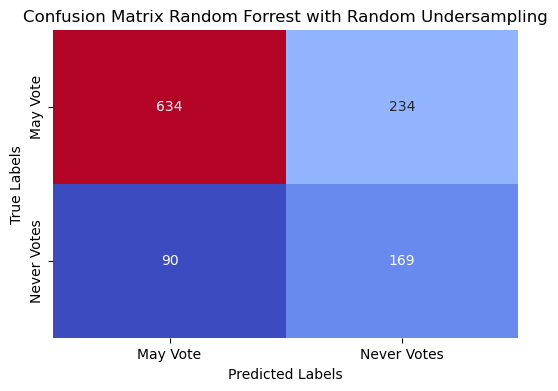

In [231]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_RF_resampled, annot=True, fmt="d", cmap="coolwarm", cbar=False,
            xticklabels=["May Vote", "Never Votes"], yticklabels=["May Vote", "Never Votes"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Random Forrest with Random Undersampling")
plt.show()

In [232]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [233]:
# find the precision, recall, and F1 score

precision = precision_score(y_test, y_pred_RF_resampled)
recall = recall_score(y_test, y_pred_RF_resampled)
f1 = f1_score(y_test, y_pred_RF_resampled)

In [234]:
print(f"Precision is: {precision:.4f}")
print(f"Recall is: {recall:.4f}")
print(f"F1-score is: {f1:.4f}")

Precision is: 0.4194
Recall is: 0.6525
F1-score is: 0.5106


In [235]:
# try a new threshold

new_threshold = 0.3
y_pred_RF_resampled_new = (y_pred_RF_resampled >= new_threshold).astype(int)

In [236]:
precision_new = precision_score(y_test, y_pred_RF_resampled_new)
recall_new = recall_score(y_test, y_pred_RF_resampled_new)
f1_new = f1_score(y_test, y_pred_RF_resampled_new)

In [237]:
print(f"Precision is: {precision_new:.4f}")
print(f"Recall is: {recall_new:.4f}")
print(f"F1-score is: {f1_new:.4f}")

Precision is: 0.4194
Recall is: 0.6525
F1-score is: 0.5106


In [238]:
# create a confusion matrix

conf_matrix_RF = confusion_matrix(y_test, y_pred_RF)
print("Confusion Matrix Random Forrest:")
print(conf_matrix_RF)

Confusion Matrix Random Forrest:
[[806  62]
 [134 125]]


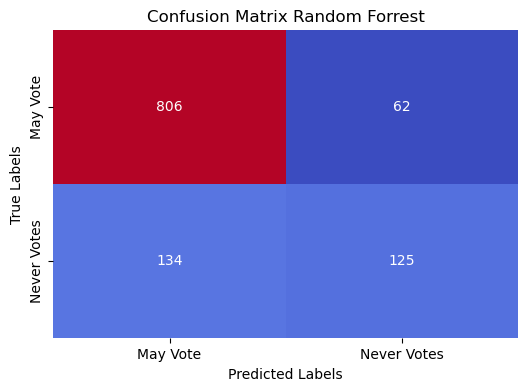

In [239]:
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_RF, annot=True, fmt="d", cmap="coolwarm", cbar=False,
            xticklabels=["May Vote", "Never Votes"], yticklabels=["May Vote", "Never Votes"])
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix Random Forrest")
plt.show()

In [240]:
# find the precision, recall, and F1 score for the original Random Forrest

precision_first = precision_score(y_test, y_pred_RF)
recall_first = recall_score(y_test, y_pred_RF)
f1_first = f1_score(y_test, y_pred_RF)

In [241]:
print(f"Precision from original RF is: {precision_first:.4f}")
print(f"Recall from original RF is: {recall_first:.4f}")
print(f"F1-score from original RF is: {f1_first:.4f}")

Precision from original RF is: 0.6684
Recall from original RF is: 0.4826
F1-score from original RF is: 0.5605


#### Findings:
- The top left 812 represents true positives, correctly predicted May Vote
- Top right 56 represents false negatives, predicted Never Votes, but May Vote
- Bottom left 137 represents false positives, predicted May Vote, but Never Votes
- Bottom right 122 represents true negatives, correctly predicted Never Votes

In [242]:
# get features with most importance

top_features = classifier_RF.feature_importances_

In [243]:
# sort features/indices in descending order

indices = np.argsort(top_features)[::-1]

In [244]:
# get feature neames

feature_names = X_train.columns

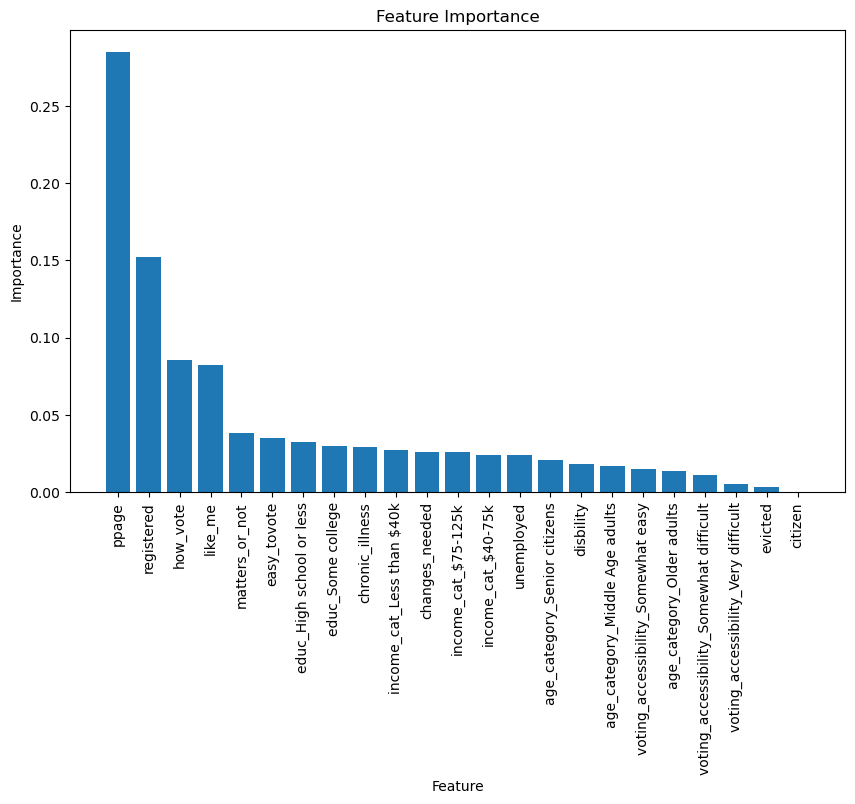

In [245]:
# plot the feature importance

plt.figure(figsize=(10, 6))
plt.bar(range(len(top_features)), top_features[indices], align="center")
plt.xticks(range(len(top_features)), [feature_names[i] for i in indices], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

#### For Random Forrest age was the feature with the highest impact. Whether someone is registered to vote is second however that was the top feature for Logisitic Regression. 

### Summary:  
I chose a Logistic Regression model because my data is binary after creating dummy variables. I chose decision tree to check non-linear relationships. I chose Random Forrest to see what features would most contribute to non voter turnout. I had already ran the 5 Best Features in Milestone 2 so I also did Logistic Regression and Decision Tree on the 5 Best Features to see if that made the accuracy improve.  

#### Logistic Regression gave the best accuracy of 0.84.  

#### Random Forrest did second best with accuracy at 0.82.

#### Logistic Regression on the 5 best features did third best at 0.78

#### Decision Tree on the 5 best features was fourth at 0.77 accuracy.  

#### Decision Tree (all features) did the worst of all models at 0.75 accuracy. 

### Updated the original Random Forrest model by performing an Undersampling technique (new code is above in the Random Forrest model section). This is to help mitigate the underperformance of the model on the minority target class, "Never Votes".  Calculated the recall for both the original Random Forrest and the new resampling model and the recall increased from 0.48 to 0.65. This higher recall means the model correctly identified 65% of the Never Votes. 